# Opis projektu
Opis + źródła zdjęć.

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Obrazy
Wczytanie obrazów, konwersja do skali szarości, różnica bezwględna obrazów oraz ich blur.

In [120]:
def to_gray(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Oryginał")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Skala szarości")
    plt.axis("off")

    plt.show()

    return gray

def abs_diff(gray_img1, gray_img2, name):
    diff = cv2.absdiff(gray_img1, gray_img2)

    plt.figure(figsize=(8, 6))
    plt.imshow(diff, cmap="gray")
    plt.title(f"Bezwzględna różnica - {name}")
    plt.axis("off")
    plt.show()

    return diff

### Pandy

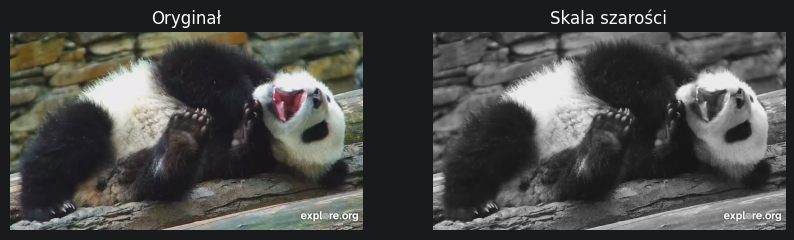

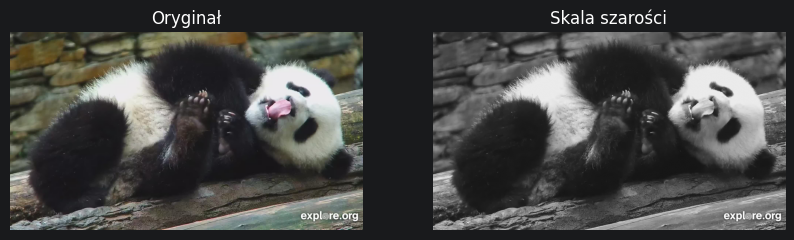

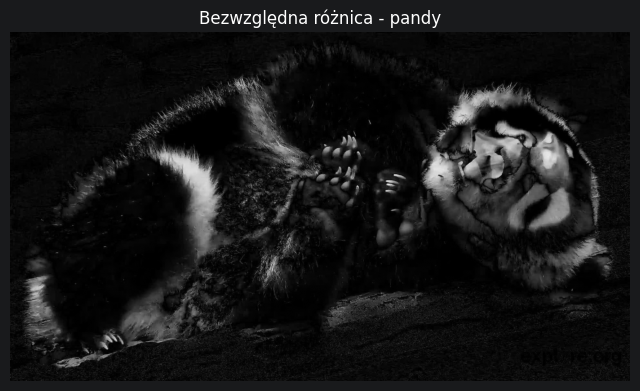

In [112]:
panda1 = cv2.imread('./obrazy/pandzia.jpg')
gray_panda1 = to_gray(panda1)

panda2 = cv2.imread('./obrazy/pandzia2.jpg')
gray_panda2 = to_gray(panda2)

diff_panda = abs_diff(gray_panda1, gray_panda2, "pandy")
blur_diff_panda = cv2.GaussianBlur(diff_panda, (5, 5), 0)

### Czaple oraz puste pole

### Rafa kolarowa

## Segmentacja
Różnica między zdjęciami, progowanie

In [113]:
def thresholding(blur_image, name):
    _, thresholded = cv2.threshold(blur_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.imshow(cv2.cvtColor(thresholded, cv2.COLOR_BGR2RGB))
    plt.title(f"Progowanie {name}")
    plt.axis("off")

    plt.show()
    return thresholded

### Pandy

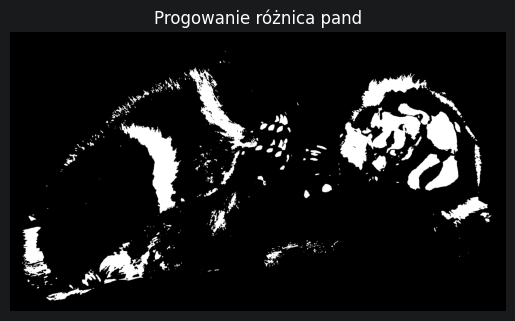

In [114]:
thresholded_diff_panda = thresholding(blur_diff_panda, "różnica pand")

### Czaple oraz puste pole

### Rafa koralowa

## Analiza
Morfologia, wykrycie konturów

In [115]:
def image_contours(image, min_contour_area):
    kernel = np.ones((5, 5), np.uint8)

    morph_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(morph_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

    return morph_image, filtered_contours

### Pandy

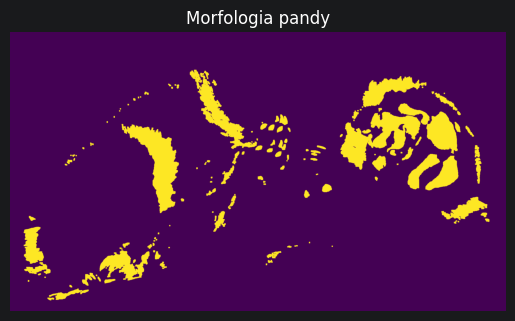

In [116]:
morph_diff_panda, diff_panda_contours = image_contours(thresholded_diff_panda, 100)
plt.imshow(morph_diff_panda)
plt.title("Morfologia pandy")
plt.axis("off")
plt.show()

### Czaple oraz puste pole

### Rafa koralowa

## Wynik
Wyświetlenie bounding box z różnicami między obrazami.

In [117]:
def show_difference(og_img2, diff_contours, title):
    image_result = og_img2.copy()
    for contour in diff_contours:
        # x, y - współrzędne bounding box'a (lewy górny róg)
        # w, h - wymiary bounding box'a (szerokość, wysokość)
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_result, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(image_result, cv2.COLOR_BGR2RGB))
    plt.title(f"Różnica {title}")
    plt.axis("off")
    plt.show()

    return image_result

### Pandy

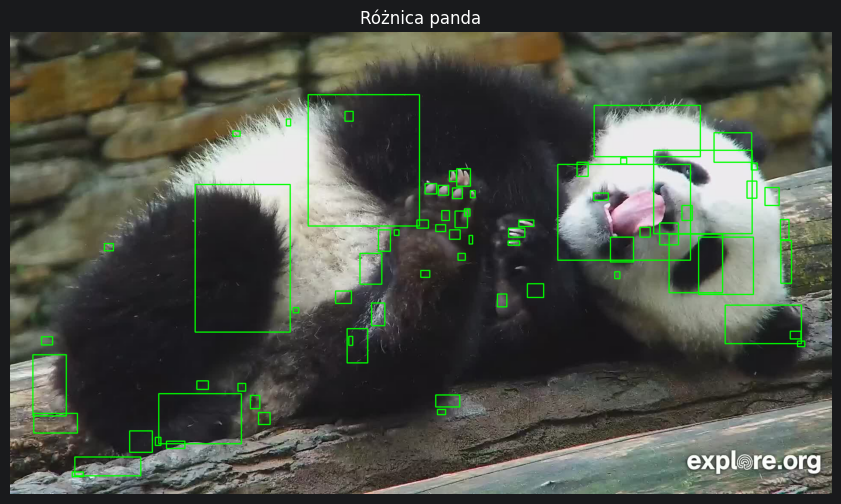

In [119]:
result_panda = show_difference(panda2, diff_panda_contours, "panda")

### Czaple oraz puste pole

### Rafa koralowa

## Podsumowanie